# Analysis of a Simulated German Power Grid (24h)

This notebook analyzes the results of a PyPSA simulation for the German power grid.

**Scenario Details:**
- **Region:** Germany 
- **Time Period:** A single day (2025-05-14)
- **Resolution:** Hourly snapshots (24 snapshots total)
- **Network Clustering:** 470 clusters

---
## 1. Setup and Configuration

### 1.1. Import Libraries

In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

### 1.2. Snakemake Workflow Commands (Reference)
The following commands were used to generate and solve the network.

```bash
# Build the network 
snakemake --cores 6 "resources/germany/networks/base_s_470_elec_.nc" --configfile config/config.germany.yaml

# Solve the network -> for line loads
snakemake -call solve_elec_networks --configfile config/config.germany.yaml
```

### 1.3. Load Network Data
Load both the unsolved (base) and solved network models from their respective `.nc` files.

In [3]:
config_name = "germany"
cluster = "470"

# Path to the network file before solving
network_path_unsolved = f"pypsa-eur/resources/{config_name}/networks/base_s_{cluster}_elec.nc"
n_unsolved = pypsa.Network(network_path_unsolved)

# Path to the network file after solving
network_path_solved = f"pypsa-eur/results/{config_name}/networks/base_s_{cluster}_elec_.nc"
n = pypsa.Network(network_path_solved)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


### Input values for the model (before solving step)

In [ ]:
# actual hourly demand values for the first few loads
n_unsolved.loads_t.p_set.head()

name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90,DE0 91,DE0 92,DE0 93,DE0 94,DE0 95,DE0 96,DE0 97,DE0 98,DE0 99
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,289.831467,310.849350,111.864609,282.097824,73.966728,5.340652,74.140434,244.746414,50.563736,524.128044,...,202.955887,135.591370,184.350510,55.434921,184.881195,421.603592,106.520699,25.496117,42.774193,143.943298
2025-05-14 01:00:00,289.238136,310.212990,111.635605,281.520325,73.815300,5.329720,73.988655,244.245377,50.460228,523.055069,...,202.540405,135.313789,183.973114,55.321442,184.502716,420.740501,106.302635,25.443924,42.686623,143.648621
2025-05-14 02:00:00,297.225868,318.779968,114.718582,289.294914,75.853821,5.476913,76.031960,250.990562,51.853760,537.499992,...,208.133850,139.050674,189.053795,56.849220,189.598030,432.359863,109.238335,26.146599,43.865479,147.615685
2025-05-14 03:00:00,320.526619,343.770439,123.711845,311.973930,81.800308,5.906265,81.992416,270.666740,55.918785,579.636818,...,224.450317,149.951431,203.874496,61.305862,204.461395,466.254318,117.801979,28.196335,47.304268,159.187881
2025-05-14 04:00:00,365.281494,391.770821,140.985626,355.534592,93.222023,6.730957,93.440948,308.459717,63.726685,660.571030,...,255.790131,170.889023,232.341324,69.865952,233.010170,531.357033,134.250572,32.133362,53.909325,181.415161


---
## 2. Network Overview and Topology
Summary of the network's components and their capacities.

### 2.1. Network Summary

In [4]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1410
 - Carrier: 21
 - Generator: 2667
 - Line: 666
 - Link: 1898
 - Load: 470
 - Store: 940
 - SubNetwork: 1
Snapshots: 24

### 2.2. Capacity and Load Analysis
A closer look at the installed capacities by carrier and the distribution of electrical load across the network buses.

- OCGT (Open Cycle Gas Turbine)
- CCGT (Combined Cycle Gas Turbine)

In [5]:
# --- Capacity and topology ---
if not n.generators.empty:
    cap_by_carrier = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
    print("Installed generator capacity by carrier [MW]:")
    display(cap_by_carrier.head(20).to_frame("p_nom_MW"))

    cap_by_bus = n.generators.groupby("bus")["p_nom"].sum().sort_values(ascending=False)
    print("\nTop buses by installed generation capacity [MW]:")
    display(cap_by_bus.head(15).to_frame("p_nom_MW"))

if not n.loads.empty and hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    annual_load_by_bus = n.loads_t.p_set.sum().sort_values(ascending=False)
    print("\nTop buses by annual load [MWh over snapshots]:")
    display(annual_load_by_bus.head(15).to_frame("load_MWh"))

if not n.lines.empty:
    print("\nLine length statistics [km]:")
    if "length" in n.lines.columns:
        display(n.lines["length"].describe().to_frame("value"))
    else:
        print("No 'length' column in n.lines")

Installed generator capacity by carrier [MW]:


,p_nom_MW
carrier,
onwind,73332.065900
solar,48771.254020
CCGT,30783.128330
coal,20351.945000
lignite,19457.035000
offwind-ac,11163.743000
biomass,8020.001833
OCGT,6112.743723
oil,5684.345986



Top buses by installed generation capacity [MW]:


,p_nom_MW
bus,
DE0 358,6615.661395
DE0 140,4622.186951
DE0 310,4616.836090
DE0 399,4281.689030
DE0 116,3952.658212
DE0 32,3930.192727
DE0 55,3235.673001
DE0 312,3185.559024
DE0 430,3103.332880



Top buses by annual load [MWh over snapshots]:


,load_MWh
name,
DE0 12,28919.592598
DE0 44,27656.320076
DE0 36,19800.852264
DE0 15,17928.510086
DE0 129,16935.742867
DE0 45,16732.389915
DE0 106,15435.780922
DE0 116,14382.988495
DE0 62,13479.436447



Line length statistics [km]:


,value
count,666.000000
mean,25.044439
std,24.795309
min,1.043104
25%,6.739575
50%,15.831136
75%,37.248927
max,206.742555


---
## 3. Geographical Visualization
This section contains plots of the network topology on a map.

### 3.1. Network Plot with Load Distribution
The plot below shows the network buses and lines. The size of each bus corresponds to its electrical load at a specific snapshot.

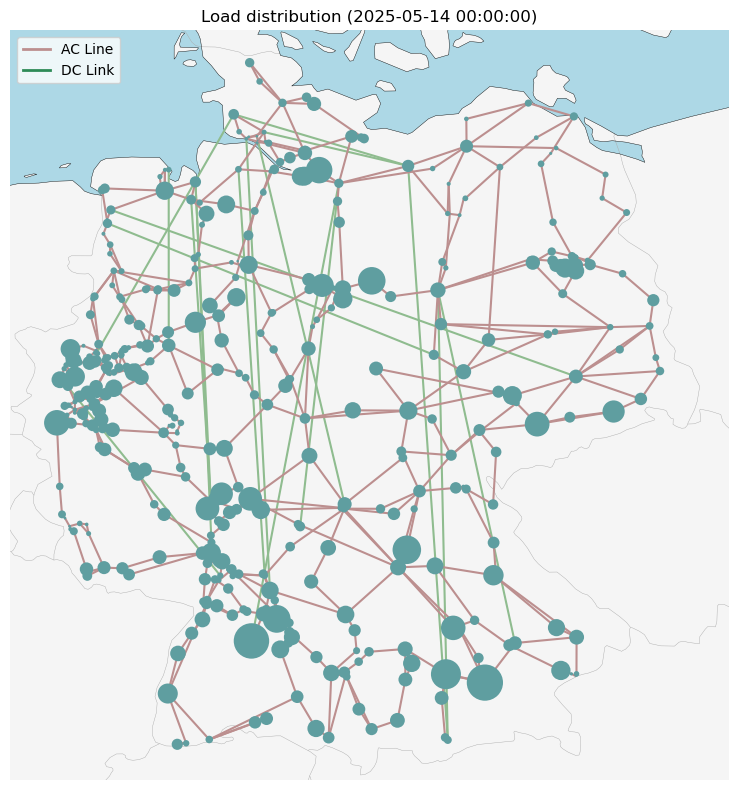

In [27]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

snapshot = n.snapshots[0]
load_distribution = n.loads_t.p_set.loc[snapshot].groupby(n.loads.bus).sum()

generator_distribution = n.generators.groupby("bus")["p_nom"].sum()

n.plot(
    bus_sizes=(load_distribution/20000),
    ax=ax,
    geomap=True,
    title=f"Load distribution ({snapshot})",
    geomap_color=True
);

# --- Add custom legend for line types ---
legend_elements = [
    Line2D([0], [0], color='rosybrown', lw=2, label='AC Line'),
    Line2D([0], [0], color='seagreen', lw=2, label='DC Link')
]
ax.legend(handles=legend_elements, loc='upper left')
# -----------------------------------------

plt.tight_layout()
plt.show()


In [25]:
n.lines.dc.head()

name
0      0.0
1      0.0
10     0.0
100    0.0
101    0.0
Name: dc, dtype: float64

### 3.1 Map with Pie Charts

In [11]:
eb = (
    n.statistics.energy_balance(
        groupby=["bus", "carrier"],
        components=["Generator", "Load", "StorageUnit"],
    )
    .groupby(["bus", "carrier"])
    .sum()
)

In [12]:
line_flow = n.lines_t.p0.sum(axis=0)
link_flow = n.links_t.p0.sum(axis=0)

In [13]:
# Define colors and order for the dispatch plot
colors = {
    "biomass": "green",
    "coal": "black",
    "lignite": "brown",
    "offwind-ac": "cyan",
    "onwind": "blue",
    "solar": "yellow",
    "gas": "orange",
    "oil": "gray",
    "ror": "turquoise",
    "geothermal": "red",
}

In [17]:
n.carriers.color = n.carriers.index.map(colors)

In [19]:
n.carriers.loc["", "color"] = "darkred"
n.carriers.loc["-", "color"] = "darkred"

In [20]:
bus_size_factor = 3e6
branch_width_factor = 2e4
branch_flow_factor = 5e4

n.plot(
    ax=ax,
    bus_size=eb / bus_size_factor,
    bus_split_circle=True,
    line_width=line_flow / branch_width_factor,
    link_width=link_flow / branch_width_factor,
    line_flow=line_flow / branch_flow_factor,
)

ValueError: Colors not defined for all elements in the second MultiIndex 

---
## 4. Data Exploration
This section includes various data checks and explorations of specific components.

- n.loads_t.p_set = demand (load) for each bus 

In [50]:
# Total load over the simulation period
loads = n.loads_t.p_set.sum().to_frame("total_load_MWh") #sum over all snapshots
print("Total load summary:")
loads

Total load summary:


,total_load_MWh
name,
DE0 0,8535.652924
DE0 1,9154.637886
DE0 10,3294.457565
DE0 100,8307.893974
DE0 101,2178.349686
...,...
DE0 95,12416.394791
DE0 96,3137.077316
DE0 97,750.870926


In [52]:
load_bus = n.loads_t.p_set.head()
load_bus

name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90,DE0 91,DE0 92,DE0 93,DE0 94,DE0 95,DE0 96,DE0 97,DE0 98,DE0 99
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,289.831467,310.849350,111.864609,282.097824,73.966728,5.340652,74.140434,244.746414,50.563736,524.128044,...,202.955887,135.591370,184.350510,55.434921,184.881195,421.603592,106.520699,25.496117,42.774193,143.943298
2025-05-14 01:00:00,289.238136,310.212990,111.635605,281.520325,73.815300,5.329720,73.988655,244.245377,50.460228,523.055069,...,202.540405,135.313789,183.973114,55.321442,184.502716,420.740501,106.302635,25.443924,42.686623,143.648621
2025-05-14 02:00:00,297.225868,318.779968,114.718582,289.294914,75.853821,5.476913,76.031960,250.990562,51.853760,537.499992,...,208.133850,139.050674,189.053795,56.849220,189.598030,432.359863,109.238335,26.146599,43.865479,147.615685
2025-05-14 03:00:00,320.526619,343.770439,123.711845,311.973930,81.800308,5.906265,81.992416,270.666740,55.918785,579.636818,...,224.450317,149.951431,203.874496,61.305862,204.461395,466.254318,117.801979,28.196335,47.304268,159.187881
2025-05-14 04:00:00,365.281494,391.770821,140.985626,355.534592,93.222023,6.730957,93.440948,308.459717,63.726685,660.571030,...,255.790131,170.889023,232.341324,69.865952,233.010170,531.357033,134.250572,32.133362,53.909325,181.415161


In [35]:
# Total nominal power by generator carrier
print("\nTotal generator nominal power by carrier [MW]:")
n.generators.groupby("carrier")["p_nom"].sum().to_frame()


Total generator nominal power by carrier [MW]:


,p_nom
carrier,
CCGT,30783.128330
OCGT,6112.743723
biomass,8020.001833
coal,20351.945000
geothermal,26.900000
lignite,19457.035000
offwind-ac,11163.743000
offwind-dc,0.000000
oil,5684.345986


In [32]:
n.lines["length"].describe().to_frame("value")

,value
count,666.000000
mean,25.044439
std,24.795309
min,1.043104
25%,6.739575
50%,15.831136
75%,37.248927
max,206.742555


In [38]:
# Inspect the processed power plants data file
print("\nHead of the processed power plants CSV:")
powerplants = pd.read_csv(f"pypsa-eur/resources/{config_name}/powerplants_s_{cluster}.csv", index_col=0)
powerplants.head()


Head of the processed power plants CSV:


,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,DateIn,DateRetrofit,DateOut,lat,lon,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,EIC,projectID,geometry,bus
0,Pumpspeicherkraftwerk Erzhausen,Hydro,Pumped Storage,Storage,DE,200.0,0.75,1964.0,1998.0,NaN,51.898566,9.924887,5.510000,1.600,287.0,1102.000000,{},"{'MASTR': {'MASTR-SEE915985628661'}, 'GEM': {'...",POINT (9.924887 51.898566),DE0 245
1,Psw Goldisthal Pss,Hydro,Pumped Storage,Storage,DE,1052.0,0.75,1970.0,2004.0,NaN,50.510000,11.010000,9.160646,12.000,302.0,9637.000000,{},"{'MASTR': {'MASTR-SEE943653719359', 'MASTR-SEE...",POINT (11.01 50.51),DE0 320
2,Koepchenwerk Bl,Hydro,Pumped Storage,Storage,DE,162.0,0.75,1970.0,1989.0,NaN,51.411382,7.454357,3.913580,1.533,155.0,634.000000,{},"{'MASTR': {'MASTR-SEE925333539921'}, 'GEM': {'...",POINT (7.454357 51.411382),DE0 377
3,Waldeck,Hydro,Pumped Storage,Storage,DE,555.0,0.75,1931.0,2009.0,NaN,51.167433,9.046337,7.151952,5.136,620.0,3969.333333,{},"{'MASTR': {'MASTR-SEE996080766151', 'MASTR-SEE...",POINT (9.046336666666669 51.16743333333333),DE0 109
4,Pumpspeicherwerk Ronkhausen Psw,Hydro,Pumped Storage,Storage,DE,138.0,0.75,1969.0,2003.0,NaN,51.227233,7.971745,5.217391,1.000,265.0,720.000000,{},"{'MASTR': {'MASTR-SEE927168175756', 'MASTR-SEE...",POINT (7.971745 51.227233),DE0 304


---
## 5. Time Series Analysis
This section visualizes the behavior of different network components over the 24-hour simulation period.

### 5.1. Generator Availability 
The `p_max_pu` (per unit maximum availability) represents the availability of renewable generators as a fraction of their nominal power.

<Axes: title={'center': 'p_max_pu for a single offwind-dc generator'}, xlabel='snapshot'>

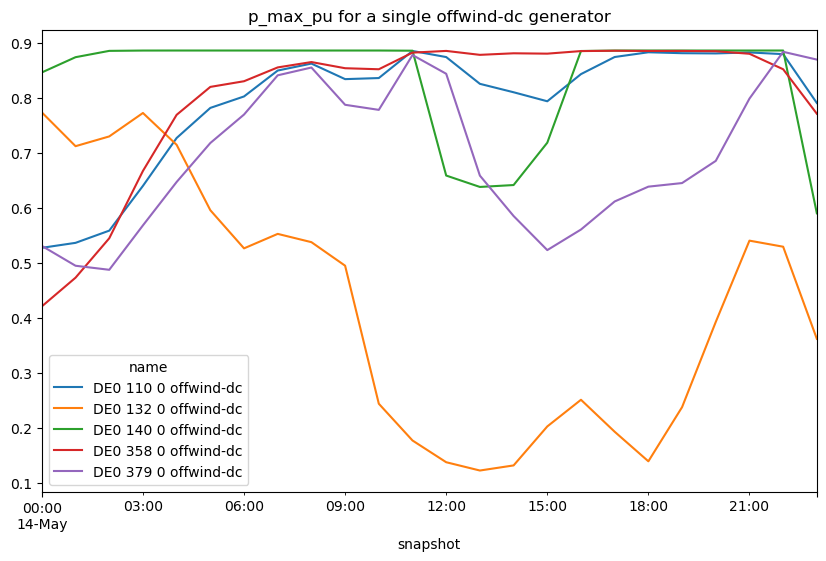

In [ ]:
# Example plot for a single offshore wind generator
n.generators_t.p_max_pu.loc["2025-05-14": "2025-05-14", "DE0 110 0 offwind-dc" : ].plot(figsize=(10, 6), title="p_max_pu for a collection of offwind-dc generators")

<Axes: title={'center': 'p_max_pu for a selection of solar generators'}, xlabel='snapshot'>

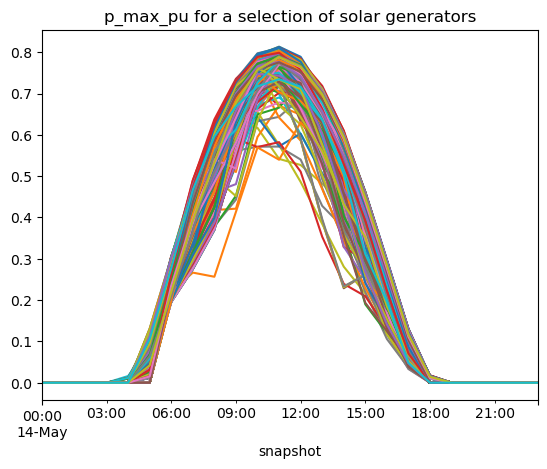

In [ ]:
# Example plot for a range of solar generators
n.generators_t.p_max_pu.loc["2025-05-14":"2025-05-14", 
                            "DE0 0 0 solar":"DE0 99 0 solar"].plot(legend=False, title="p_max_pu for a selection of solar generators")

#### Average Availability per Carrier
The following plots show the average `p_max_pu` for all generators of a specific carrier type. This provides a clearer view than plotting every single generator.

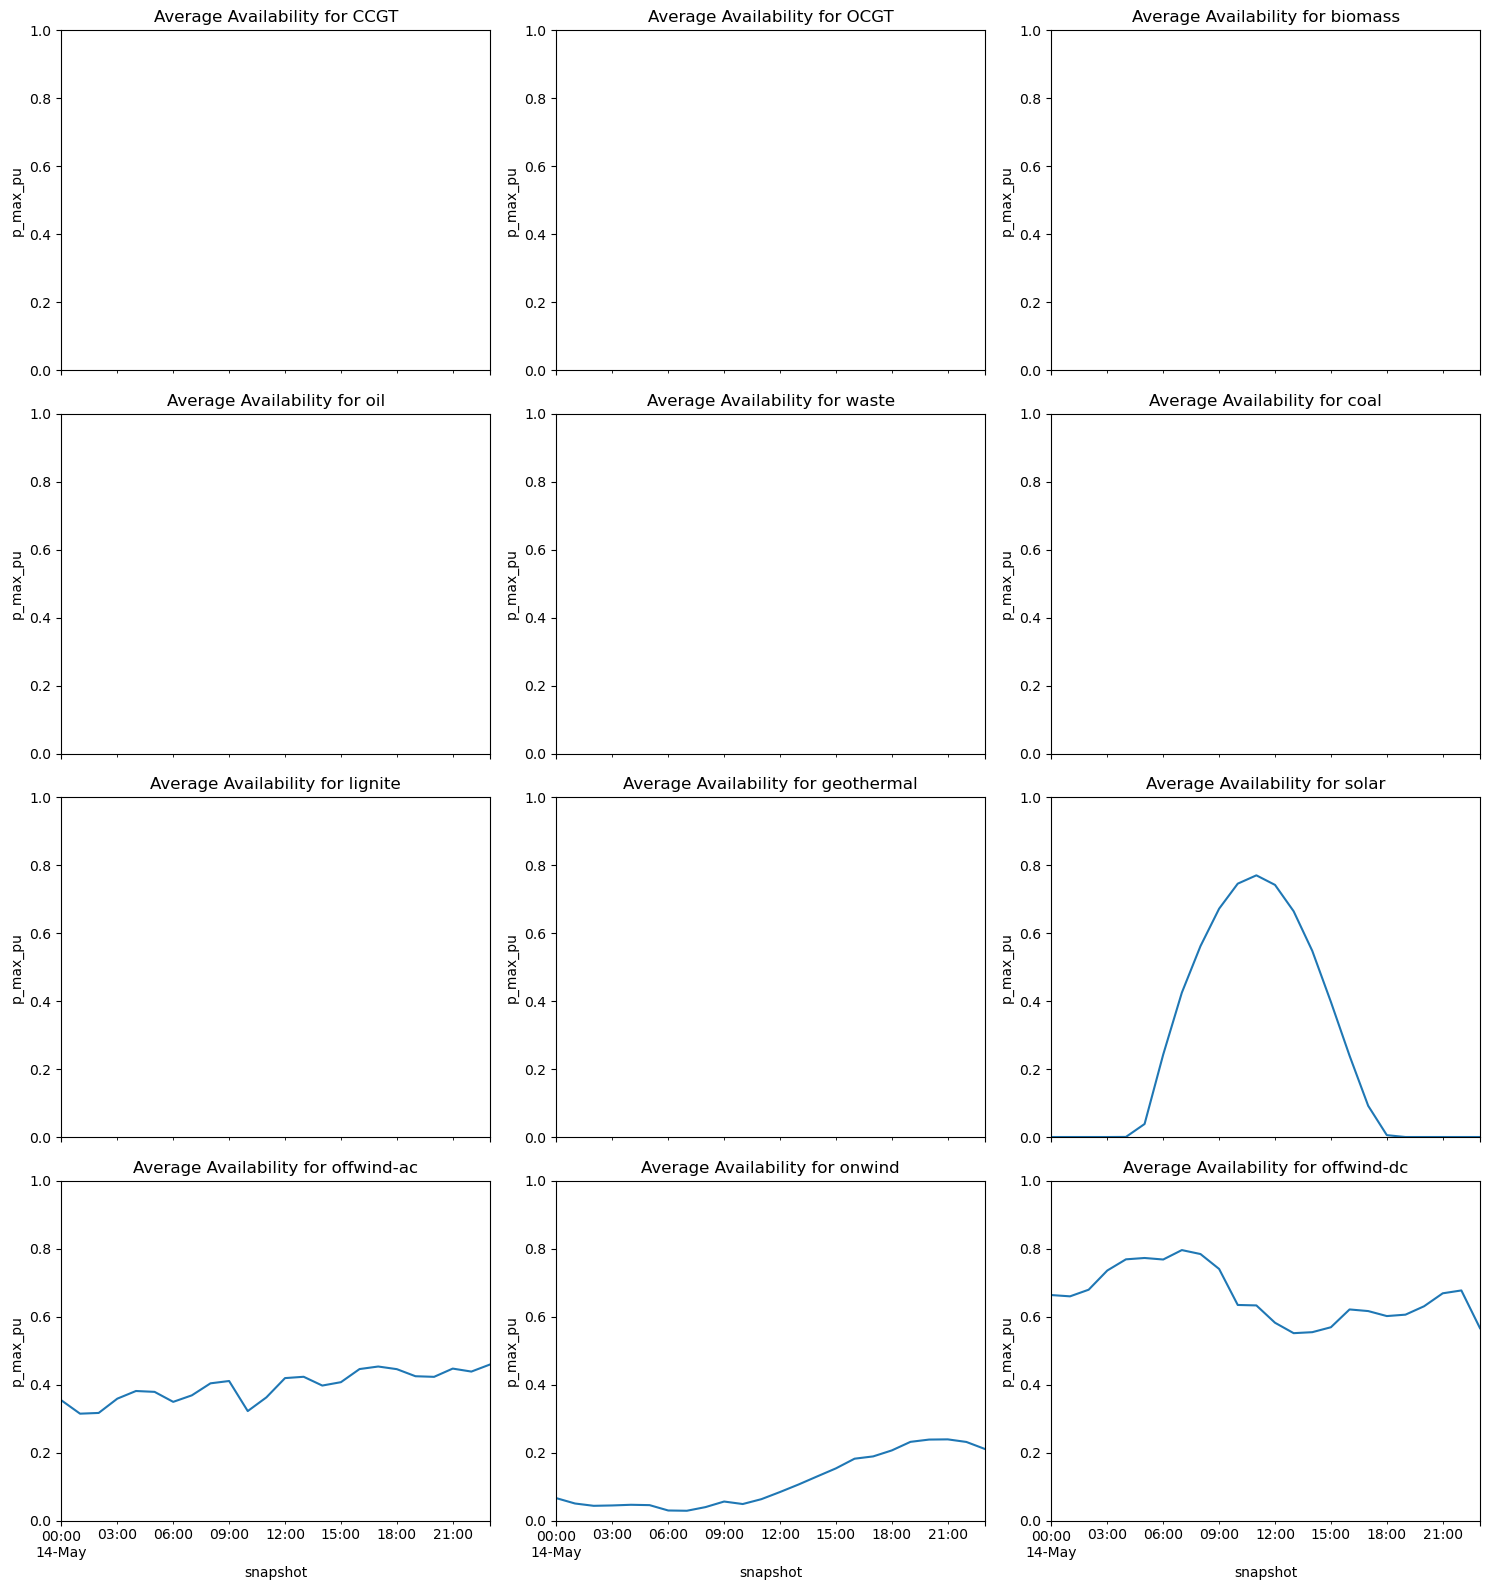

In [ ]:
# Get all unique carriers
carriers = n.generators.carrier.unique()

# Create a figure with subplots for each carrier
n_carriers = len(carriers)
n_cols = 3
n_rows = (n_carriers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, carrier in enumerate(carriers):
    ax = axes[i]
    
    # Find all generators for the current carrier
    gens_for_carrier = n.generators.index[n.generators.carrier == carrier]
    
    # Find the intersection of generators for the carrier and columns in p_max_pu
    common_gens = n.generators_t.p_max_pu.columns.intersection(gens_for_carrier)
    
    # Plot the AVERAGE p_max_pu for these generators
    if not common_gens.empty:
        p_max_pu_carrier = n.generators_t.p_max_pu[common_gens]
        p_max_pu_carrier.mean(axis=1).plot(ax=ax, legend=False)
    
    ax.set_title(f"Average Availability for {carrier}")
    ax.set_ylabel("p_max_pu")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 5.2. Power Dispatch by Carrier
This plot shows the total power generated (dispatched) by each carrier type over time.

In [ ]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
# Drop carriers with very low production for clarity
to_drop = p_by_carrier.max()[p_by_carrier.max() < 1700].index
p_by_carrier.drop(to_drop, axis=1, inplace=True)
print("Carriers included in dispatch plot:")
p_by_carrier.columns

Carriers included in dispatch plot:


Index(['biomass', 'coal', 'lignite', 'offwind-ac', 'onwind', 'solar'], dtype='object', name='carrier')

In [ ]:
# Define colors and order for the dispatch plot
colors = {
    "biomass": "green",
    "coal": "black",
    "lignite": "brown",
    "offwind-ac": "cyan",
    "onwind": "blue",
    "solar": "yellow",
    "gas": "orange",
    "oil": "gray",
    "ror": "turquoise",
    "geothermal": "red",
}
# Reorder columns for a conventional stack
cols = [
    "lignite",
    "coal",
    "biomass",
    "onwind",
    "offwind-ac",
    "solar",
]
p_by_carrier = p_by_carrier[cols]

Text(0.5, 0, '')

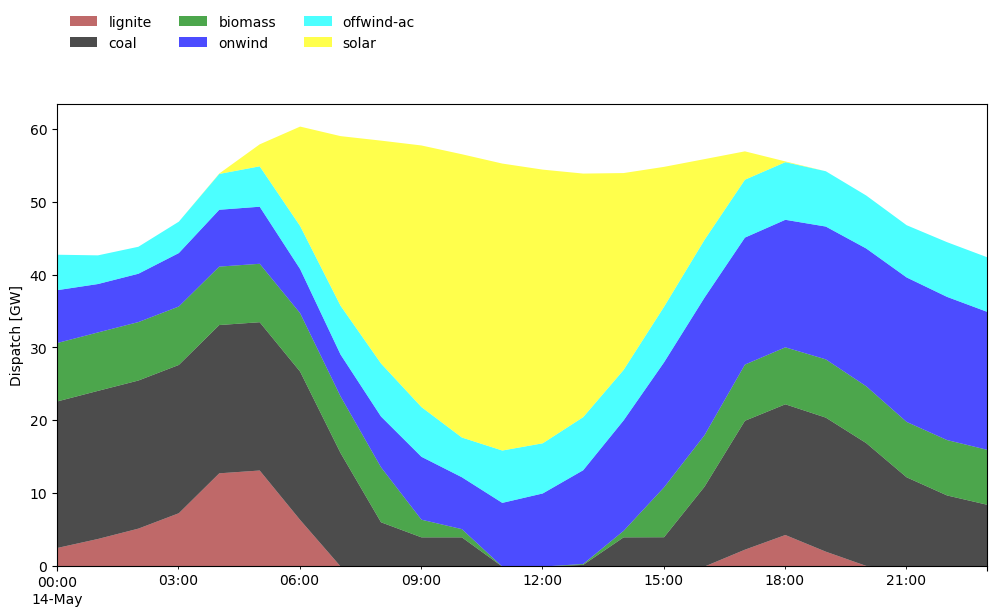

In [ ]:
c = [colors[col] for col in p_by_carrier.columns]
fig, ax = plt.subplots(figsize=(12, 6))
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=c, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("Dispatch [GW]")
ax.set_xlabel("")

### Storage Behavior (CURRENTLY NO STORAGE)
This plot shows the dispatch and state of charge for storage units (e.g., pumped hydro).

Text(0.5, 0, '')

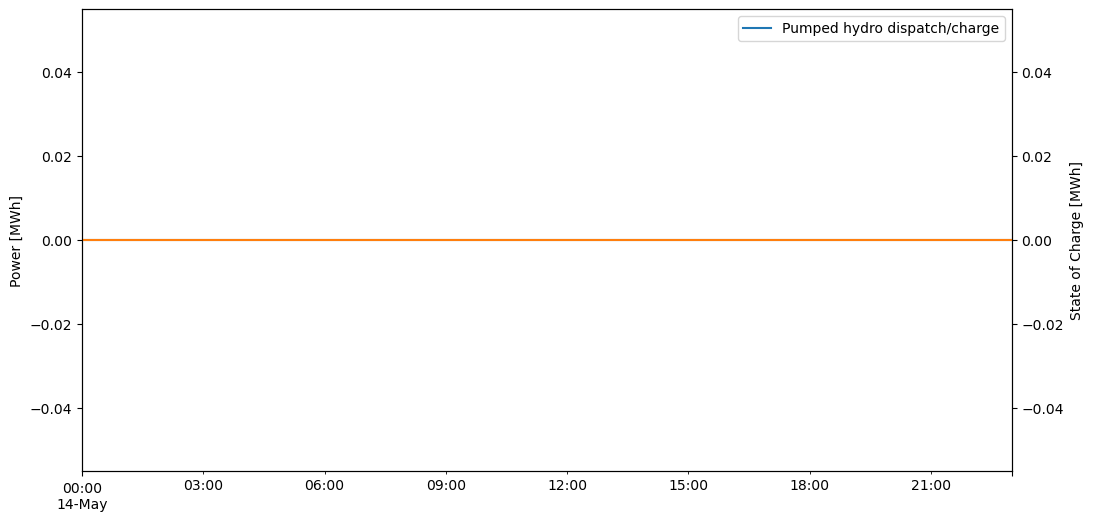

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

p_storage = n.storage_units_t.p.sum(axis=1)
state_of_charge = n.storage_units_t.state_of_charge.sum(axis=1)
p_storage.plot(label="Pumped hydro dispatch/charge", ax=ax)
state_of_charge.plot(label="State of charge", ax=ax, secondary_y=True)

ax.axhline(0, color="k", lw=0.5, ls="--")
ax.legend()
ax.set_ylabel("Power [MWh]")
ax.right_ax.set_ylabel("State of Charge [MWh]")
ax.set_xlabel("")

---
## 6. Grid Analysis
This section focuses on the state of the transmission grid itself, including line loading and curtailment.

### 6.1. Line Loading
Line loading is the ratio of the power flowing through a line to its nominal capacity.

In [ ]:
# Select a snapshot to analyze
now = n.snapshots[18]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
print(f"Line loading statistics for snapshot {now}:")
loading.describe()

Line loading statistics for snapshot 2025-05-14 18:00:00:


count    666.000000
mean      -0.006925
std        0.411936
min       -3.470228
25%       -0.205081
50%       -0.003108
75%        0.196417
max        3.442529
dtype: float64

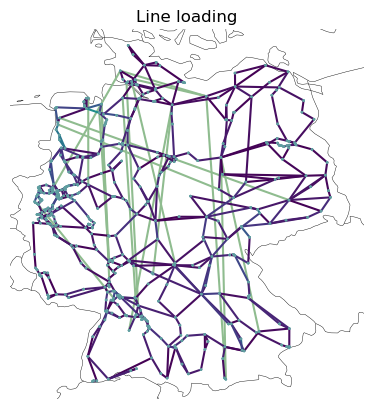

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()})
n.plot(
    ax=ax,
    line_color=loading.abs(),
    line_cmap="viridis",
    title="Line loading",
    bus_size=1e-3,
);

### 6.2. Curtailment Analysis
Curtailment is the reduction in the output of a generator from what it could otherwise produce. Here we calculate and plot it for a specific carrier.

In [ ]:
carrier = "onwind"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

In [ ]:
p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity

In [ ]:
# Correct for any minor negative values from floating point inaccuracies
p_df.loc[p_df[f"{carrier} curtailed"] < 0, f"{carrier} curtailed"] = 0

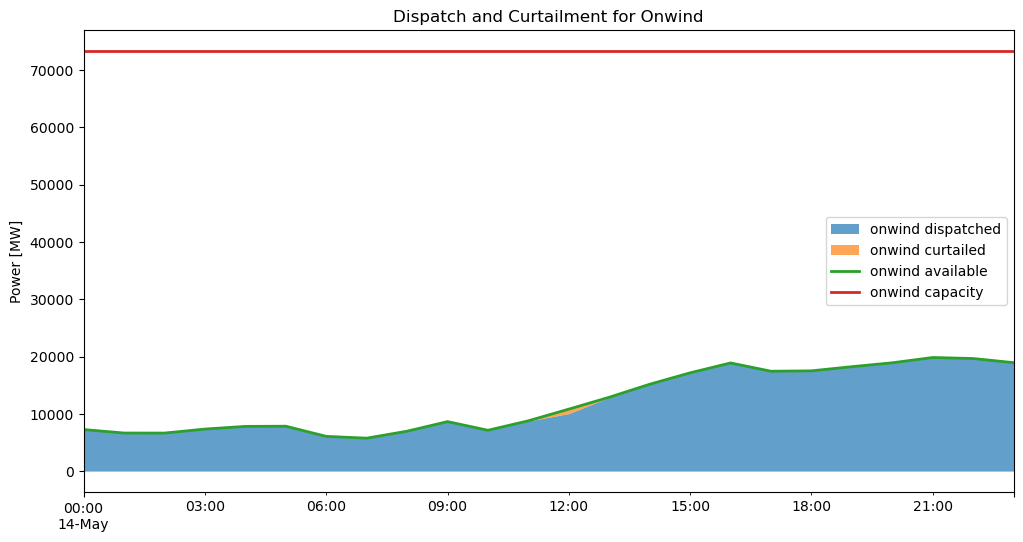

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0, alpha=0.7)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax, lw=2)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Dispatch and Curtailment for {carrier.title()}")
ax.legend()


### 5.3. Load Profile for a busses (Demand)
electricity demand (load) over the 24-hour period 

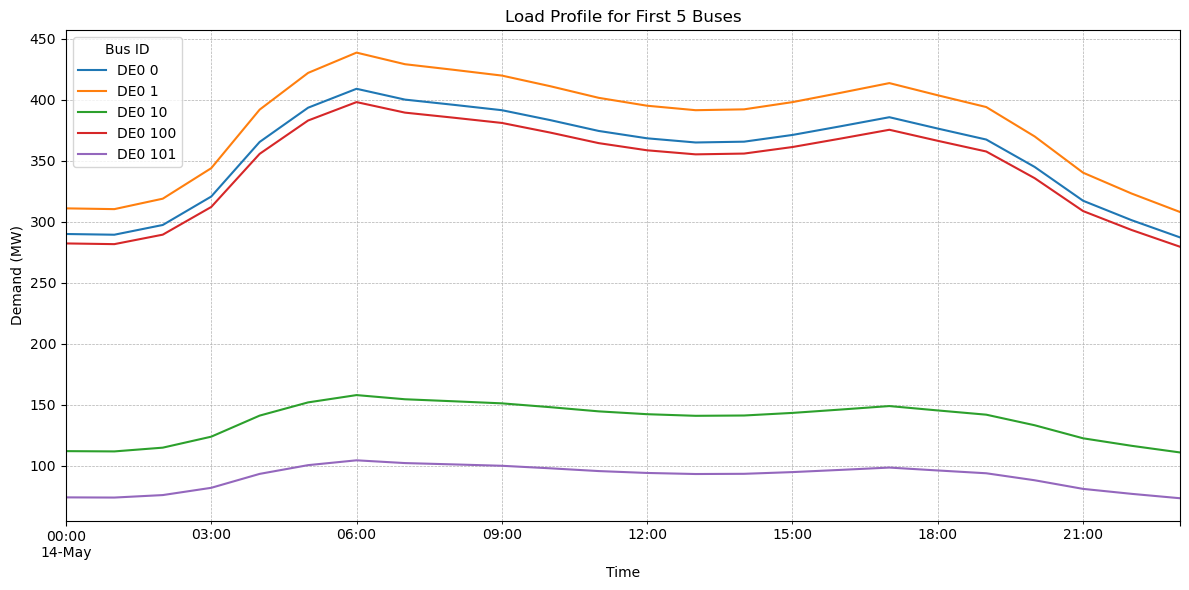

In [59]:

# --- Plot load for multiple buses ---

# Choose buses to inspect (e.g., the first 5)
buses_to_plot = n.buses.index[:5]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

for bus in buses_to_plot:
    # Find all loads connected to this bus
    loads_on_bus = n.loads[n.loads.bus == bus].index
    
    # Get the time-series data for these loads and sum them up
    if not loads_on_bus.empty:
        load_profile = n.loads_t.p_set[loads_on_bus].sum(axis=1)
        load_profile.plot(ax=ax, label=bus)

ax.set_title("Load Profile for First 5 Buses")
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("Time")
ax.legend(title="Bus ID")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


### 5.3. Statistics 

In [ ]:
n.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.consistency:Network sanitization complete.


(<Figure size 411.111x400 with 1 Axes>,
 <Axes: xlabel='Installed Capacity [MW]', ylabel='carrier'>,
 <seaborn.axisgrid.FacetGrid at 0x79bf2ff33390>)

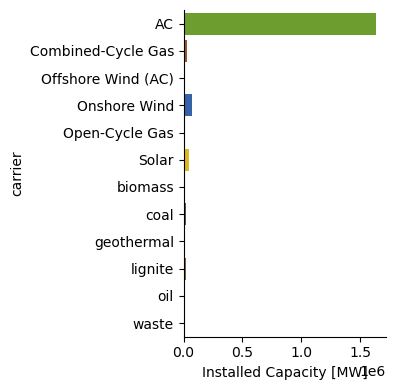

In [ ]:
n.statistics.installed_capacity.plot()

In [ ]:
n.statistics.energy_balance.iplot.area()